In [3]:
from ultralytics import YOLO
import torch

In [2]:
model = YOLO('yolov8n.pt')  # Hoặc yolov8s.pt nếu muốn lớn hơn

In [5]:
# Huấn luyện
results = model.train(
    data='../dataset/data.yaml',
    epochs=50,                 
    imgsz=640,                 
    batch=16,                 
    name='license_plate_model',  
    device='0' if torch.cuda.is_available() else 'cpu'  # Sử dụng GPU nếu có
)

Ultralytics 8.3.221  Python-3.12.12 torch-2.9.0+cpu CPU (Intel Core i5-10300H 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=license_plate_model2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

In [8]:
from ultralytics import YOLO

# Đường dẫn đúng đến file best.pt
model = YOLO('../runs/detect/license_plate_model2/weights/best.pt')


In [11]:
from ultralytics import YOLO

# Load mô hình YOLO đã fine-tune
model = YOLO('../runs/detect/license_plate_model2/weights/best.pt')

# Đánh giá (validation)
results = model.val(data='../dataset/data.yaml')

# In các chỉ số đánh giá
print(f"Precision: {float(results.box.p.mean()):.4f}")
print(f"Recall: {float(results.box.r.mean()):.4f}")
print(f"mAP@0.5: {float(results.box.map50.mean()):.4f}")
print(f"mAP@0.5:0.95: {float(results.box.map.mean()):.4f}")



Ultralytics 8.3.221  Python-3.12.12 torch-2.9.0+cpu CPU (Intel Core i5-10300H 2.50GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 405.8679.5 MB/s, size: 129.8 KB)
val: Scanning C:\QLDA\GiuaKy\backend_ai\ai_data\dataset\valid\labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 190.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 0.7it/s 24.7s1.2ss
                   all        287        307      0.878       0.89      0.925      0.765
                 Human        171        191      0.892      0.832      0.894       0.58
               NoHuman        116        116      0.864      0.948      0.955      0.949
Speed: 1.2ms preprocess, 72.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to C:\QLDA\GiuaKy\backend_ai\ai_data\notebook\runs\detect\val3
Precision: 0.8782
Recall: 0.8904
m

File tồn tại: True

image 1/1 c:\QLDA\GiuaKy\backend_ai\ai_data\notebook\..\dataset\test\images\image_7202_jpeg.rf.3b9581c2283821910ba89500d8c5b7b1.jpg: 448x640 1 Human, 109.3ms
Speed: 2.3ms preprocess, 109.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


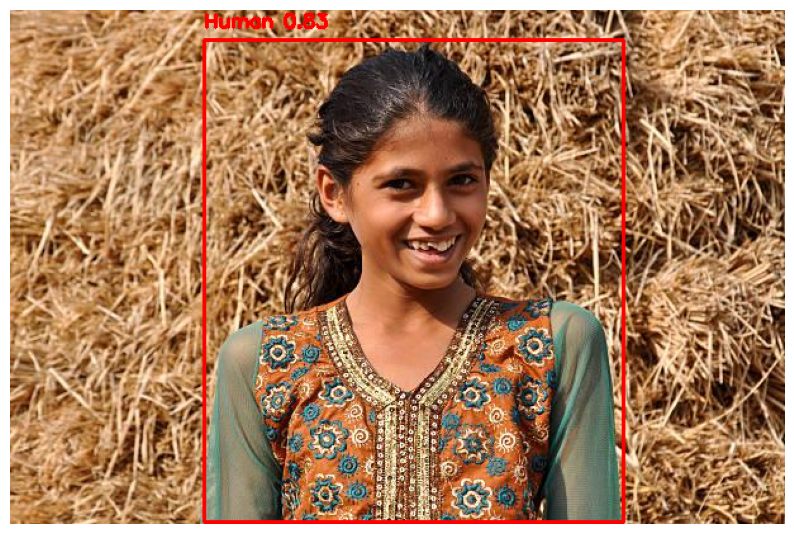

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


model = YOLO('runs/detect/license_plate_model2/weights/best.pt')


img_path = '../dataset/test/images/image_7202_jpeg.rf.3b9581c2283821910ba89500d8c5b7b1.jpg'


import os
print("File tồn tại:", os.path.exists(img_path))


results = model(img_path)


img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh: {img_path}")


for result in results:
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy()

    for box, conf, cls in zip(boxes, confs, classes):
        x1, y1, x2, y2 = map(int, box)
        label = f"{model.names[int(cls)]} {conf:.2f}"

     
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
       
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)



img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()


🖼️ Ảnh tồn tại không: True
